In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # pyright: ignore[reportMissingModuleSource]
from sklearn.cluster import KMeans as sklKMeans
from sklearn.metrics import silhouette_score

In [6]:
data = pd.read_csv("C:/Users/Asus/Desktop/dl_lab/samples/Iris.csv")
X = data[["SepalLengthCm", "PetalLengthCm"]]

def kMeans(X, k):
	distortion = []
	model = None
	for i in range(1, k + 1):
		model = sklKMeans(n_clusters=i, init="random", n_init="auto", max_iter=10).fit(X.values)
		distortion.append(model.inertia_)
		if i > 1:
			print(f"Silhouette Score for {i} clusters is {silhouette_score(X, model.labels_)}")
	return model, distortion

k = 5
model, distortion = kMeans(X, k)


Silhouette Score for 2 clusters is 0.7096825580716465
Silhouette Score for 3 clusters is 0.5890612473759282
Silhouette Score for 4 clusters is 0.5645625259696128
Silhouette Score for 5 clusters is 0.5615794939538516


Text(0, 0.5, 'Distortion')

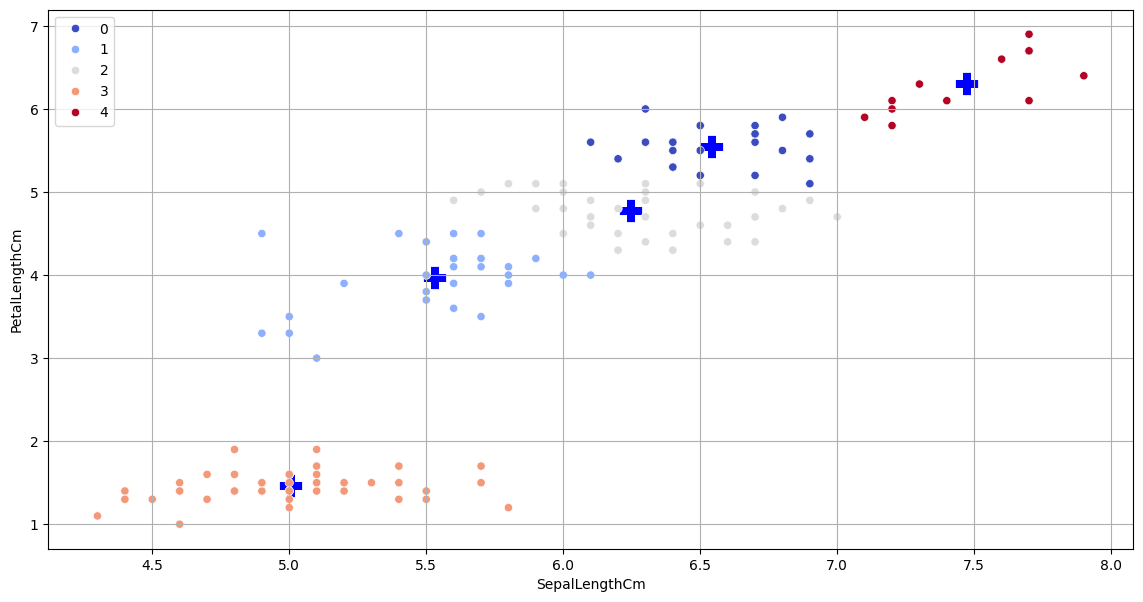

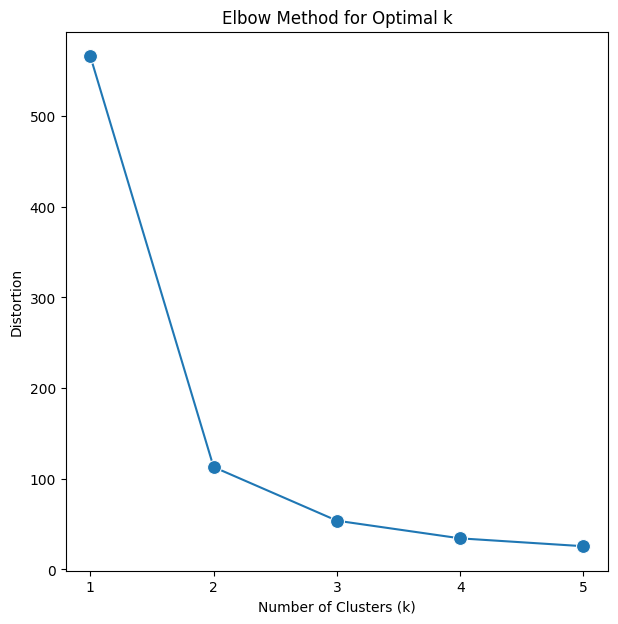

In [7]:
centroids = model.cluster_centers_
index = model.labels_

plt.figure(figsize=(14, 7))
plt.scatter(x=centroids[:, 0], y=centroids[:, 1], marker="+", c="b", linewidth=16)
sns.scatterplot(data=data, x="SepalLengthCm", y="PetalLengthCm", hue=index, palette="coolwarm")
plt.grid()
plt.savefig("K-Means_iris")

plt.figure(figsize=(7, 7))
sns.lineplot(x=np.arange(1, k + 1), y=np.array(distortion), marker="o", markersize=10)
plt.xticks(np.arange(1, k + 1))
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Distortion")